In [2]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

: 

<h3><b>Bisection algorithm</h3>

2.0945515632629395


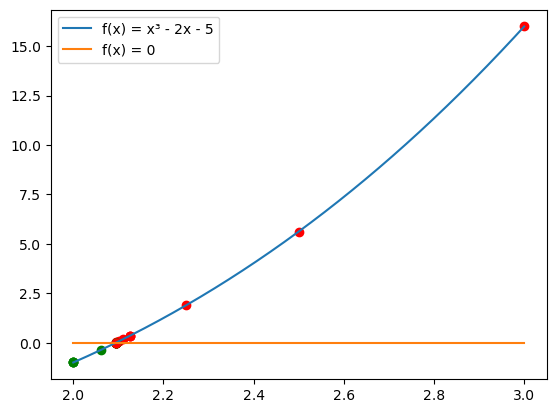

In [3]:
def bissecao(f, a: float, b: float, err: float):
    
    xm = (b + a)/2
    plt.scatter(a, f(a), color='g')
    plt.scatter(b, f(b), color='r')

    if abs(b - a) < err:
        return xm

    if f(a) * f(xm) < 0:
        return bissecao(f, a, xm, err)
    return bissecao(f, xm, b, err)
    

a = 2
b = 3
x = np.linspace(a, b, 1000)
f = lambda x: x**3 - 2 * x - 5
err = 1.0e-6

print(bissecao(f, a, b, err))

plt.plot(x, f(x), label="f(x) = x³ - 2x - 5")
plt.plot(x, np.zeros(1000), label="f(x) = 0")
plt.legend()
plt.show()


<h3><b>Newton algorithm</h3>

(1.41421356237384, 10)


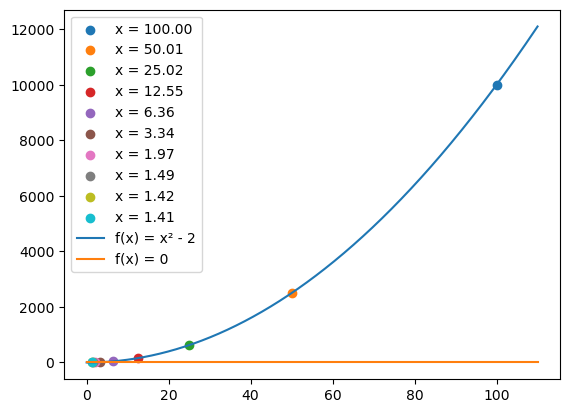

In [4]:
def newton(x0, err, func, dfunc):

    xk1 = x0
    iter = 0

    while abs(func(xk1)) > err:
        plt.scatter(xk1, func(xk1), label="x = {:.2f}".format(xk1))
        xk1 = xk1 - func(xk1)/dfunc(xk1)
        iter += 1

    return xk1, iter

x0 = 100.0
err = 1.0e-6
x_axis = np.linspace(0, 1.1 * x0, 1000)

func = lambda x: x**2 - 2
dfunc = lambda x: 2*x

print(newton(x0, err, func, dfunc))
plt.plot(x_axis, func(x_axis), label="f(x) = x² - 2")
plt.plot(x_axis, np.zeros(1000), label="f(x) = 0")
plt.legend()
plt.show()

<h3><b>Secant algorithm</h3>

1.4142135620573204


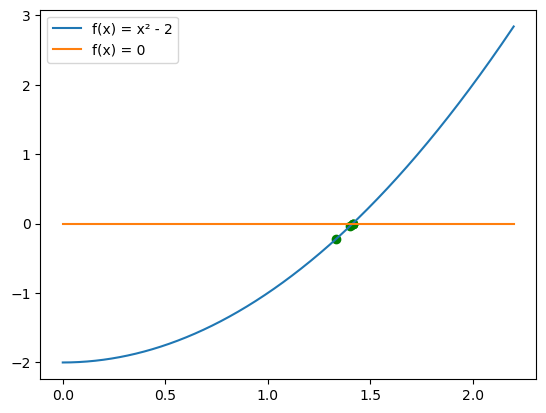

In [5]:
def secante(f, xk_minus1, xk, err):
    
    xk_plus1 = (xk_minus1 * f(xk) - xk * f(xk_minus1)) / (f(xk) - f(xk_minus1))

    plt.scatter(xk_plus1, f(xk_plus1), color="g")
    if abs(f(xk_plus1)) < err:
        return xk_plus1
    
    return secante(f, xk, xk_plus1, err)


x0 = 1
x1 = 2
err = 1.0e-6
f = lambda x: x**2 - 2
x = np.linspace(0, 1.1 * x1, 1000)

print(secante(f, x0, x1, err))
plt.plot(x, f(x), label="f(x) = x² - 2")
plt.plot(x, np.zeros(1000), label="f(x) = 0")
plt.legend()
plt.show()

<h3><b>Lagrange polynomial interpolation</h3>

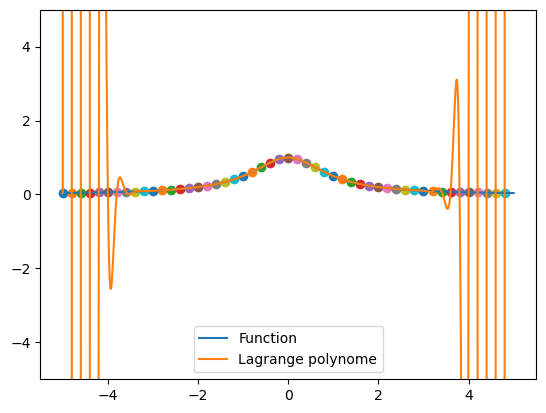

In [6]:
def lagrange(x: np.linspace, pontos):
    polinomio = 0

    for i in range(len(pontos)):

        produtorio = 1

        for j in range(len(pontos)):
            if i != j:
                produtorio *= (x - pontos[j][0]) / (pontos[i][0] - pontos[j][0])
        polinomio += pontos[i][1] * produtorio

    return polinomio
        
n = 50
x = np.linspace(-5, 5, 1000)
f = lambda x: 1 / (1 + x ** 2)
# pontos = np.random.uniform(-5, 5, size=(10, 2))

pontos = [((-5 + 10 * i/n), f((-5 + 10 * i/n))) for i in range(0, n)]

polin = lagrange(x, pontos)

for i in range(len(pontos)):
    plt.scatter(pontos[i][0], pontos[i][1])

plt.plot(x, f(x), label="Function")
plt.plot(x, polin, label="Lagrange polynome")
plt.ylim(-5, 5)
plt.legend()
plt.show()


<h3><b>MMQ</h3>

[0.89968, 1.32664, 1.7536, 2.18056, 2.60752]


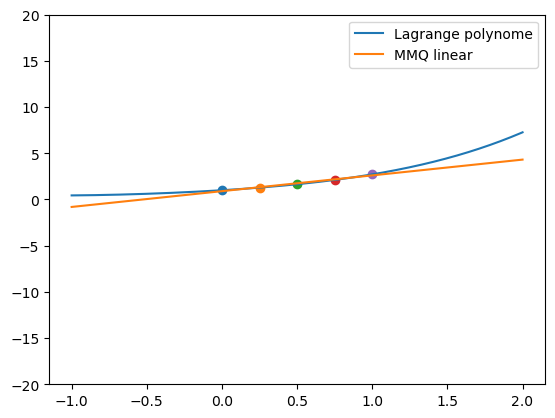

[0.8986285714285712, 1.3263771428571427, 1.7541257142857143, 2.1818742857142857, 2.609622857142857, 3.0373714285714284]


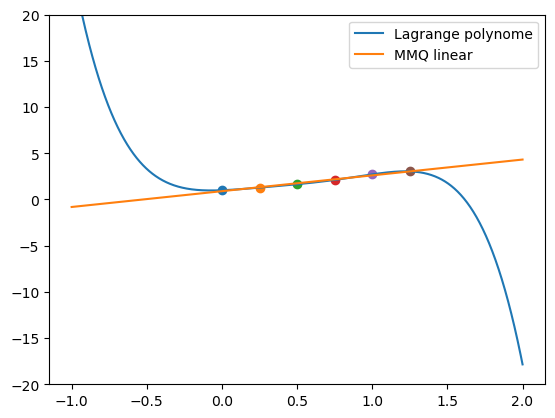

[0.9459714285714284, 1.3453142857142857, 1.744657142857143, 2.144, 2.5433428571428576, 2.9426857142857146, 3.342028571428572]


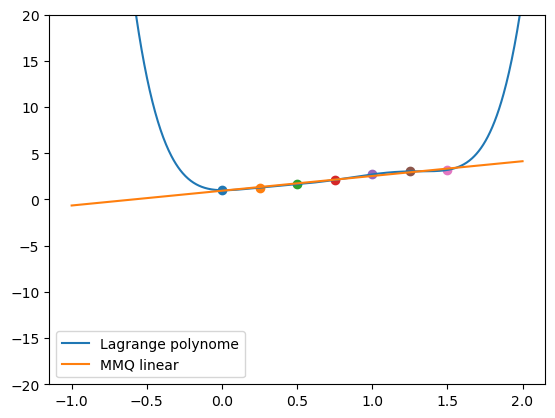

In [7]:
def mmq(pontos):
    n = len(pontos)
    sum_x = sum([p[0] for p in pontos])
    sum_y = sum([p[1] for p in pontos])
    sum_x2 = sum([p[0] ** 2 for p in pontos])
    sum_xy = sum([p[0] * p[1] for p in pontos])
    
    a = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
    b = (sum_y - a * sum_x) / n

    return b, a

def repeat(pontos):

    polin_lagrange = lagrange(x, pontos)
    coef = mmq(pontos)

    f = lambda x: coef[0] + coef[1] * x

    valores_reta = [f(pontos[p][0]) for p in range(len(pontos))]
    print(valores_reta)

    for i in range(len(pontos)):
        plt.scatter(pontos[i][0], pontos[i][1])

    plt.plot(x, polin_lagrange, label="Lagrange polynome")
    plt.plot(x, f(x), label="MMQ linear")
    plt.ylim(-20, 20)
    plt.legend()
    plt.show()

x = np.linspace(-1, 2, 1000)
pontos = [(0.0, 1.0), (0.25, 1.2840), (0.5, 1.6487), (0.75, 2.1170), (1.00, 2.7183)]

repeat(pontos)
pontos.append((1.25, 3.04))
repeat(pontos)
pontos.append((1.5, 3.20))
repeat(pontos)

1.499969482421875 1.500030517578125


/tmp/ipykernel_2764/1339342255.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


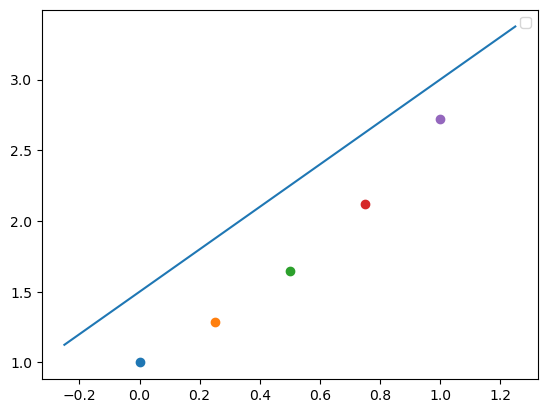

In [63]:
def equacao_normal(degree:int, pontos:list):
    X = np.array([[p[0] ** i for i in range(0, degree + 1)] for p in pontos])
    Y = np.array([p[1] for p in pontos])
    return np.dot(np.linalg.inv(np.dot(X.T, X)), np.dot(X.T, Y))

def mmq_polinomial(degree:int, pontos: list):
    theta = equacao_normal(degree, pontos)
    f = lambda n: sum([theta[i] * n**i for i in range(len(theta))])
    plt.plot(x, f(x), label="Grau " + str(degree))

def mmq_generico():
    # X = np.array([[p[0] ** i for i in range(0, degree + 1)] for p in pontos])
    X = np.array([(1, 1), (1, 1.00001), (1, 1)])
    Y = np.array([3, 3.00001, 2.99999])
    theta = np.dot(np.linalg.inv(np.dot(X.T, X)), np.dot(X.T, Y))

    

    print(theta[0], theta[1])
    f = lambda n: sum([theta[i] * n**i for i in range(len(theta))])
    plt.plot(x, f(x))


x = np.linspace(-0.25, 1.25, 1000)
pontos = [(0.0, 1.0), (0.25, 1.2840), (0.5, 1.6487), (0.75, 2.1170), (1.00, 2.7183)]
# pontos = np.random.uniform(-0.25, 1.25, size=(10, 2))
# plt.ylim(-0.5, 1.5)

for i in range(len(pontos)):
    plt.scatter(pontos[i][0], pontos[i][1])

# [mmq_polinomial(i, pontos) for i in range(1, 3)]
mmq_generico()
# mmq_polinomial(10, pontos)
# poli = lagrange(x, pontos)
# plt.plot(x, poli, label="Lagrange polynome")
plt.legend()

In [51]:
import numpy as np

def compute_cost(X, Y, theta):
    m = len(Y)
    predictions = X.dot(theta)
    errors = predictions - Y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost

def gradient_descent(X, Y, theta, alpha, num_iters):
    m = len(Y)
    cost_history = []

    for i in range(num_iters):
        predictions = X.dot(theta)
        errors = predictions - Y
        gradient = (1 / m) * X.T.dot(errors)
        theta = theta - alpha * gradient
        cost = compute_cost(X, Y, theta)
        cost_history.append(cost)

    return theta, cost_history

# Exemplo de uso
X = np.array([(1, 1), (1, 1.00001), (1, 0.99999)])
Y = np.array([3, 3.00001, 2.99999])
# X = np.array([[1, 1], [1, 2], [1, 3]])
# Y = np.array([1, 2, 3])
theta = np.zeros(2)
alpha = 0.01
num_iters = 1000

theta, cost_history = gradient_descent(X, Y, theta, alpha, num_iters)
print(theta)

[1.5 1.5]


In [62]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = np.array([(1, 1), (1, 1.00001), (1, 1)])
Y = np.array([3, 3.00001, 2.99999])

model = LinearRegression()
model.fit(X, Y)

intercept = model.intercept_
coefficients = model.coef_

print("Intercepto:", intercept)
print("Coeficiente angular:", coefficients[1])
print("Coeficientes:", coefficients)


Intercepto: 1.4999949999999997
Coeficiente angular: 1.5000000000000002
Coeficientes: [0.  1.5]
